<a href="https://colab.research.google.com/github/mpconsultsai/msc-project-csc-40098/blob/main/training/notebooks/training_fusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab — Multimodal fusion (RQ2 / RQ3)

One notebook; **run cells top-to-bottom** after a runtime restart (Bootstrap → Setup → Steps 1–5). Steps 2–4 can be re-run separately once `train_df` / `val_df` exist.

| Step | Section | Typical time (T4)* |
|------|---------|-------------------|
| **1** | Setup + multimodal cohort load | few min (+ image unzip on first run) |
| **2** | Late fusion (logistic combiner) | ~20–40 min |
| **3** | Early fusion (concat → linear) | ~20–40 min |
| **4** | Attention fusion (softmax gates) | ~20–40 min |
| **5** | RQ2/RQ3 summary table | seconds |

\*Encoder scoring / embedding extraction dominates; early and attention each re-read all images.

**Methods reference:** `training/README.md` (Fusion methods)

**Split policy:** Fakeddit official + FNN 80/20 stratified, seed **42** (via `cohort_multimodal.py`).

**Validation outputs (Steps 2–4):** `metrics.json` (macro-F1, per-class recall, ROC-AUC, AP), `confusion_matrix.png`, `roc_pr_curves.png`, `predictions_val.tsv`. Step 5 fills missing unimodal recall from `predictions_val.tsv` when needed.

## How to run this notebook (Google Colab)

**What it does:** runs the **multimodal fusion** experiments (late, early, and attention) and a comparison table (RQ2 / RQ3). Needs a **GPU runtime** (a free T4 is sufficient).

> **Run the two unimodal notebooks first.** Fusion reuses the trained DistilBERT and ResNet-18 checkpoints. Run `training_text_distilbert.ipynb` and `training_image_resnet.ipynb` to completion first — they save checkpoints to `My Drive/runs/`, which this notebook pulls back in during setup. If they are missing, setup will report the required checkpoints are not found.

**Before you run:**
1. **Add the shared project folder to your Google Drive** (one-time) so these paths exist — the setup cell reads them:
   - `My Drive/training/src/` — helper modules (`colab_setup.py`, `cohort_*.py`)
   - `My Drive/data/fake_news_final_text.tsv` and `My Drive/data/fake_news_final_image.tsv`
   - `My Drive/data/images.zip` — cohort images (~1.3 GB); extracted automatically (first run takes a few minutes)
   - `My Drive/runs/` — the DistilBERT + ResNet checkpoints from the two unimodal notebooks

   If the folder was *shared with you*, open it in Drive and click **“Add shortcut to Drive”** so it appears under `My Drive/`.
2. **Set the runtime:** `Runtime → Change runtime type → T4 GPU`.
3. **(Recommended)** `File → Save a copy in Drive` so your edits and outputs persist.

**Then `Runtime → Run all`** (or run the cells top to bottom in order):
- **Bootstrap** — mounts Drive and copies `training/` into the session.
- **Dependencies** — `install_dependencies(["text", "image"])` installs the pinned libraries.
- **Setup** — `require_cuda()` checks the GPU, copies the TSVs, extracts images, and syncs `runs/` from Drive.
- The remaining cells score the frozen encoders and fit/evaluate the three fusion methods.

> **Troubleshooting**
> - `No module named 'google'` → you’re not on a hosted Colab runtime. Open this in the Colab browser tab and connect to a **hosted** runtime (not “local”).
> - `No module named 'colab_setup'` → the **Bootstrap** cell hasn’t run successfully yet, or `My Drive/training/src/` is missing. Run Bootstrap first and confirm the Drive layout above.
> - Missing-checkpoint error in setup → run the DistilBERT and ResNet notebooks first (see note above).

## Setup

Run the bootstrap + setup cells below in order. Setup checks the GPU, copies the TSVs, extracts the images, and syncs the unimodal checkpoints from `My Drive/runs/`.

In [1]:
# Bootstrap — mount Drive and copy training/ (identical cell in all Colab notebooks)
import shutil
import sys
from pathlib import Path

from google.colab import drive

drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/msc")
TRAINING_SRC = Path("/content/drive/MyDrive/training")
TRAINING = PROJECT_ROOT / "training"
if not TRAINING_SRC.is_dir():
    raise FileNotFoundError(
        "Sync repo training/ to My Drive/training/ (modules under training/src/)"
    )
if TRAINING.exists():
    shutil.rmtree(TRAINING)
shutil.copytree(TRAINING_SRC, TRAINING)
sys.path.insert(0, str(TRAINING / "src"))
print("PROJECT_ROOT:", PROJECT_ROOT, "| training:", TRAINING)

Mounted at /content/drive
PROJECT_ROOT: /content/msc | training: /content/msc/training


In [2]:
from colab_setup import install_dependencies

# Pinned, version-synced installs (single source of truth: colab_setup.PINNED_DEPENDENCIES).
# torch/torchvision are left to Colab's preinstalled, CUDA-matched build.
install_dependencies(["text", "image"])

Installing pinned dependencies: scikit-learn==1.5.2 pandas==2.2.2 transformers==4.44.2 datasets==2.21.0 accelerate==0.34.2 Pillow==11.1.0 pillow-heif==0.21.0 tqdm==4.66.5
Resolved dependency versions:
    scikit-learn: 1.5.2
          pandas: 2.2.2
    transformers: 4.44.2
        datasets: 2.21.0
      accelerate: 0.34.2
          Pillow: 11.1.0
     pillow-heif: 0.21.0
            tqdm: 4.66.5
           torch: 2.11.0+cu128
     torchvision: 0.26.0+cu128


{'scikit-learn': '1.5.2',
 'pandas': '2.2.2',
 'transformers': '4.44.2',
 'datasets': '2.21.0',
 'accelerate': '0.34.2',
 'Pillow': '11.1.0',
 'pillow-heif': '0.21.0',
 'tqdm': '4.66.5',
 'torch': '2.11.0+cu128',
 'torchvision': '0.26.0+cu128'}

### `colab_setup` — GPU, TSVs, images, training helpers

In [3]:
from colab_setup import require_cuda, setup_colab_project, sync_runs_from_drive

require_cuda()
ctx = setup_colab_project(
    tsv_names=["fake_news_final_text.tsv", "fake_news_final_image.tsv"],
    need_images=True,
)
PROJECT_ROOT = ctx.project_root

# Pull unimodal checkpoints from My Drive/runs/ (saved by DistilBERT + ResNet notebooks)
sync_runs_from_drive(PROJECT_ROOT)

CUDA: True | GPU: Tesla T4
VRAM GB: 15.6
TSV: /content/msc/data/fake_news_final_text.tsv
TSV: /content/msc/data/fake_news_final_image.tsv
Training helpers: /content/msc/training
Zip candidate: /content/drive/MyDrive/data/images.zip | 1293.9 MB | first bytes: b'PK\x03\x04'
Copying zip to Colab disk (~2–5 min)... /content/drive/MyDrive/data/images.zip
Testing zip integrity (unzip -t)...
Zip OK: /content/images_local.zip (1.29 GB)
Unzipping with system unzip (~3–8 min)... /content/images_local.zip
Unzipped 46478 images -> /content/msc/data/processed/images
Setup OK: ColabSetup(project_root=PosixPath('/content/msc'), data_dir=PosixPath('/content/msc/data'), training_dir=PosixPath('/content/msc/training'), images_dir=PosixPath('/content/msc/data/processed/images'), image_count=46478, tsv_paths={'fake_news_final_text.tsv': PosixPath('/content/msc/data/fake_news_final_text.tsv'), 'fake_news_final_image.tsv': PosixPath('/content/msc/data/fake_news_final_image.tsv')})
Synced runs: /content/driv

PosixPath('/content/msc/runs')

## Step 1 — Multimodal cohort load

Joins text + image on `sample_id`, applies the same `split_study` policy, and **drops rows whose image file is missing** on disk.

Outputs in memory: `df_mm`, `train_df`, `val_df`, `load_stats`, `summary`.

**Note:** On Colab, `rows_missing_image` may be ~3k (image baseline used ~41,382 train / 4,486 val). Document that in thesis limitations.

In [4]:
import pandas as pd
from IPython.display import display

from cohort_image import verify_jpeg_payloads
from cohort_multimodal import (
    MULTIMODAL_COLUMNS,
    cohort_stats,
    load_multimodal_cohort,
    train_val_frames,
)

df_mm, load_stats = load_multimodal_cohort(PROJECT_ROOT)
jpeg_stats = verify_jpeg_payloads(df_mm, PROJECT_ROOT)
print("JPEG payload check:", jpeg_stats)
train_df, val_df = train_val_frames(df_mm)
summary = cohort_stats(df_mm)

print("Load stats:")
for k, v in load_stats.items():
    print(f"  {k}: {v:,}" if isinstance(v, int) else f"  {k}: {v}")

print("\nSummary:")
for k, v in summary.items():
    print(f"  {k}: {v}")

assert train_df["label_binary"].isin([0, 1]).all()
assert val_df["label_binary"].isin([0, 1]).all()
assert train_df["text"].str.strip().ne("").all()

missing_train = int((~train_df["cohort_image_local_path"].map(
    lambda p: (PROJECT_ROOT / p).is_file()
)).sum())
missing_val = int((~val_df["cohort_image_local_path"].map(
    lambda p: (PROJECT_ROOT / p).is_file()
)).sum())
print(f"\nSpot-check missing files: train={missing_train}, val={missing_val}")

display(train_df[MULTIMODAL_COLUMNS].head(3))
print("\nStep 1 complete. Continue to Step 2 — late fusion below.")

JPEG payload check: {'rows_checked': 45868, 'rows_ok': 45868}
Load stats:
  rows_text_cohort: 48,878
  rows_after_join: 48,878
  rows_missing_image: 3,010
  rows_kept: 45,868
  rows_train: 41,382
  rows_validation: 4,486

Summary:
  rows_total: 45868
  rows_train: 41382
  rows_validation: 4486
  label_train: {0: 17898, 1: 23484}
  label_val: {0: 1938, 1: 2548}
  dataset_train: {'fakeddit': 40340, 'fakenewsnet': 1042}
  dataset_val: {'fakeddit': 4219, 'fakenewsnet': 267}

Spot-check missing files: train=0, val=0


,sample_id,dataset,split_study,label_binary,text,cohort_image_local_path
0,fd:2vkbtj,fakeddit,train,1,bride and groom exchange vows after fatal shoo...,data/processed/images/fd_2vkbtj.jpg
1,fd:98vrcq,fakeddit,train,0,jesus christ converting local teens to christi...,data/processed/images/fd_98vrcq.jpg
2,fd:bjmfr7,fakeddit,train,1,the way the rain made a silhouette of my bike,data/processed/images/fd_bjmfr7.jpg



Step 1 complete. Continue to Step 2 — late fusion below.


---

## Step 2 — Late fusion (logistic combiner)

**Idea:** keep DistilBERT and ResNet-18 **frozen**. For each post, get two scores — `score_text` and `score_image` (probability of fake). Train a **logistic regression** on those two numbers (train split only), then evaluate on validation.

```
score_text  ──┐
              ├── LogisticRegression → P(fake) → macro-F1
score_image ──┘
```

**Checkpoints:** DistilBERT and ResNet notebooks **auto-save to `My Drive/runs/`** after training. Fusion setup syncs them into `/content/msc/runs/` automatically.

**One-time:** if you trained before auto-persist was added, re-run the unimodal **save/eval** cells once.

Always uses the **full multimodal train set** (41,382 rows) and **4,486** validation rows.


In [5]:
# Step 2a — verify unimodal checkpoints (synced from Drive in setup cell above)
import sys

import torch

sys.path.insert(0, str(PROJECT_ROOT / "training" / "src"))

from fusion_common import IMAGE_RUN_ID, TEXT_RUN_ID, require_unimodal_artifacts

if "train_df" not in globals() or "val_df" not in globals():
    raise RuntimeError("Run Step 1 first (defines train_df / val_df).")

text_model_dir, image_weights = require_unimodal_artifacts(PROJECT_ROOT)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Text model:", text_model_dir)
print("Image weights:", image_weights)
print("Device:", device)
print("Multimodal train/val:", len(train_df), len(val_df))

Text model: /content/msc/runs/text_distilbert_baseline/model
Image weights: /content/msc/runs/image_resnet18_baseline/resnet18_state.pt
Device: cuda
Multimodal train/val: 41382 4486


In [6]:
# Step 2b — score train/val with frozen encoders
import time

import pandas as pd
from IPython.display import display

from fusion_common import RANDOM_SEED
from fusion_late import (
    fit_late_fusion_combiner,
    predict_late_fusion,
    score_image,
    score_text,
)

TEXT_BATCH = 64
IMAGE_BATCH = 64

train_scoring = train_df
print(f"Scoring full train: {len(train_scoring)} rows")

t0 = time.perf_counter()
print("Scoring text (DistilBERT)...")
score_text_train = score_text(
    train_scoring,
    text_model_dir,
    device=device,
    batch_size=TEXT_BATCH,
)
score_text_val = score_text(
    val_df,
    text_model_dir,
    device=device,
    batch_size=TEXT_BATCH,
)
print(f"  text done in {(time.perf_counter() - t0) / 60:.1f} min")

t1 = time.perf_counter()
print("Scoring image (ResNet-18)...")
score_image_train = score_image(
    train_scoring,
    image_weights,
    project_root=PROJECT_ROOT,
    device=device,
    batch_size=IMAGE_BATCH,
)
score_image_val = score_image(
    val_df,
    image_weights,
    project_root=PROJECT_ROOT,
    device=device,
    batch_size=IMAGE_BATCH,
)
print(f"  image done in {(time.perf_counter() - t1) / 60:.1f} min")

preview = val_df[["sample_id", "label_binary"]].copy()
preview["score_text"] = score_text_val
preview["score_image"] = score_image_val
display(preview.head())

Scoring full train: 41382 rows
Scoring text (DistilBERT)...
  text done in 2.8 min
Scoring image (ResNet-18)...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]


  image done in 4.2 min


,sample_id,label_binary,score_text,score_image
42954,fd:151xr9,1,0.872824,0.868328
42955,fd:ba8djo,1,0.914406,0.881013
42956,fd:9cjhoa,0,0.003831,0.143383
42957,fd:9am49y,0,0.051889,0.020200
42958,fd:d7hb1v,1,0.986711,0.466430


Combiner weights (text, image): [6.14959265 3.90710916]
Combiner intercept: -5.239675055236277

Late fusion validation metrics (threshold=0.5):
  accuracy: 0.8406
  macro_f1: 0.8386
  f1_real: 0.8207
  f1_fake: 0.8566
  recall_real: 0.8442
  recall_fake: 0.8379
  roc_auc: 0.9147
  average_precision: 0.9258

              precision    recall  f1-score   support

    real (0)       0.80      0.84      0.82      1938
    fake (1)       0.88      0.84      0.86      2548

    accuracy                           0.84      4486
   macro avg       0.84      0.84      0.84      4486
weighted avg       0.84      0.84      0.84      4486



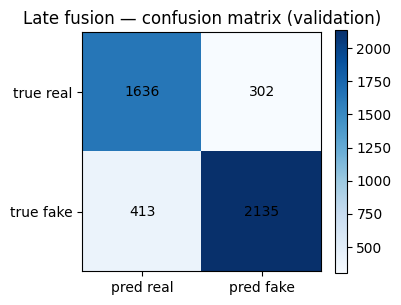

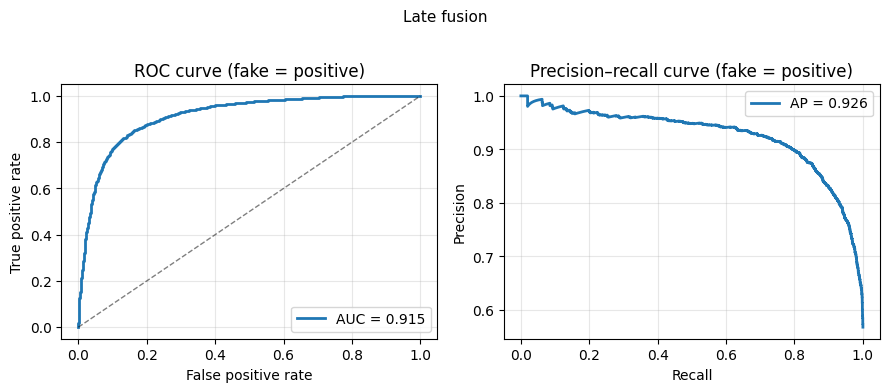

Persisted to Drive: /content/drive/MyDrive/runs/fusion_late_logistic

Saved to /content/msc/runs/fusion_late_logistic
  confusion_matrix.png, roc_pr_curves.png, metrics.json, predictions_val.tsv
{
  "accuracy": 0.840615247436469,
  "macro_f1": 0.8386184387121737,
  "f1_real": 0.8206671682969652,
  "f1_fake": 0.8565697091273822,
  "recall_real": 0.8441692466460269,
  "recall_fake": 0.8379120879120879,
  "roc_auc": 0.91472682190285,
  "average_precision": 0.925808757777513,
  "run_id": "fusion_late_logistic",
  "fusion_type": "late_logistic",
  "train_rows": 41382,
  "val_rows": 4486,
  "text_run_id": "text_distilbert_baseline",
  "image_run_id": "image_resnet18_baseline",
  "split_policy": "fakeddit_official_plus_fnn_80_20_seed_42",
  "random_seed": 42,
  "combiner_coef_text": 6.149592647906365,
  "combiner_coef_image": 3.907109158184795,
  "combiner_intercept": -5.239675055236277
}

Step 2 complete.


In [7]:
# Step 2c — fit combiner, evaluate, save artefacts
import json

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

from colab_setup import persist_run_to_drive
from fusion_common import (
    IMAGE_RUN_ID,
    RANDOM_SEED,
    TEXT_RUN_ID,
    plot_validation_figures,
    save_validation_figures,
)
from fusion_late import (
    FUSION_RUN_ID,
    evaluate_scores,
    fit_late_fusion_combiner,
    predict_late_fusion,
    save_fusion_run,
)

y_train = train_scoring["label_binary"].to_numpy()
y_val = val_df["label_binary"].to_numpy()

combiner = fit_late_fusion_combiner(score_text_train, score_image_train, y_train)
print("Combiner weights (text, image):", combiner.coef_[0])
print("Combiner intercept:", float(combiner.intercept_[0]))

y_pred, score_fused = predict_late_fusion(combiner, score_text_val, score_image_val)
metrics = evaluate_scores(y_val, y_pred, score_fused)
metrics.update(
    {
        "run_id": FUSION_RUN_ID,
        "fusion_type": "late_logistic",
        "train_rows": int(len(train_scoring)),
        "val_rows": int(len(val_df)),
        "text_run_id": TEXT_RUN_ID,
        "image_run_id": IMAGE_RUN_ID,
        "split_policy": "fakeddit_official_plus_fnn_80_20_seed_42",
        "random_seed": RANDOM_SEED,
        "combiner_coef_text": float(combiner.coef_[0][0]),
        "combiner_coef_image": float(combiner.coef_[0][1]),
        "combiner_intercept": float(combiner.intercept_[0]),
    }
)

print("\nLate fusion validation metrics (threshold=0.5):")
for k in (
    "accuracy",
    "macro_f1",
    "f1_real",
    "f1_fake",
    "recall_real",
    "recall_fake",
    "roc_auc",
    "average_precision",
):
    print(f"  {k}: {metrics[k]:.4f}")
print()
print(classification_report(y_val, y_pred, target_names=["real (0)", "fake (1)"]))

fig_cm, fig_curves = plot_validation_figures(
    y_val, y_pred, score_fused, title_prefix="Late fusion"
)
plt.show()

pred_out = val_df[["sample_id", "dataset"]].copy()
pred_out["y_true"] = y_val
pred_out["y_pred"] = y_pred
pred_out["score_text"] = score_text_val
pred_out["score_image"] = score_image_val
pred_out["score_fused"] = score_fused

run_dir = PROJECT_ROOT / "runs" / FUSION_RUN_ID
save_fusion_run(run_dir, metrics=metrics, val_predictions=pred_out, combiner=combiner)
save_validation_figures(run_dir, fig_cm, fig_curves)
persist_run_to_drive(run_dir)

print("\nSaved to", run_dir)
print("  confusion_matrix.png, roc_pr_curves.png, metrics.json, predictions_val.tsv")
print(json.dumps(metrics, indent=2))
print("\nStep 2 complete.")

---

## Step 3 — Early fusion (concat → linear head)

**Fusion point:** **Feature level** — before classification.

**Method (standard early fusion):**

1. Extract **frozen** embeddings: DistilBERT `[CLS]` (768-d) + ResNet pooled vector (512-d).
2. **Concatenate** → single **linear** layer → fake/real logits.
3. Train **only the linear head** on train; evaluate on val (same 4,486 rows).

Encoders are **not** fine-tuned again (common when combining strong unimodal backbones).

See `training/README.md` (Early fusion) for thesis wording and ML rationale.

Extracting train embeddings (41382 rows)...
Extracting val embeddings (4486 rows)...
Training early fusion head...
  epoch 1/8 train loss: 0.2490
  epoch 2/8 train loss: 0.2302
  epoch 3/8 train loss: 0.2263
  epoch 4/8 train loss: 0.2264
  epoch 5/8 train loss: 0.2212
  epoch 6/8 train loss: 0.2226
  epoch 7/8 train loss: 0.2212
  epoch 8/8 train loss: 0.2186

Early fusion validation metrics (threshold=0.5):
  accuracy: 0.8350
  macro_f1: 0.8340
  f1_real: 0.8206
  f1_fake: 0.8474
  recall_real: 0.8731
  recall_fake: 0.8061
  roc_auc: 0.9193
  average_precision: 0.9322

              precision    recall  f1-score   support

    real (0)       0.77      0.87      0.82      1938
    fake (1)       0.89      0.81      0.85      2548

    accuracy                           0.84      4486
   macro avg       0.83      0.84      0.83      4486
weighted avg       0.84      0.84      0.84      4486



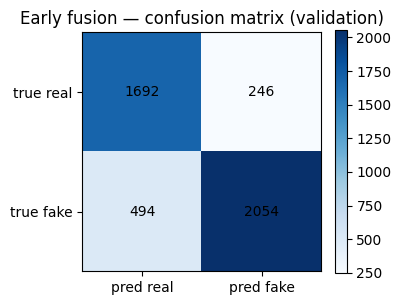

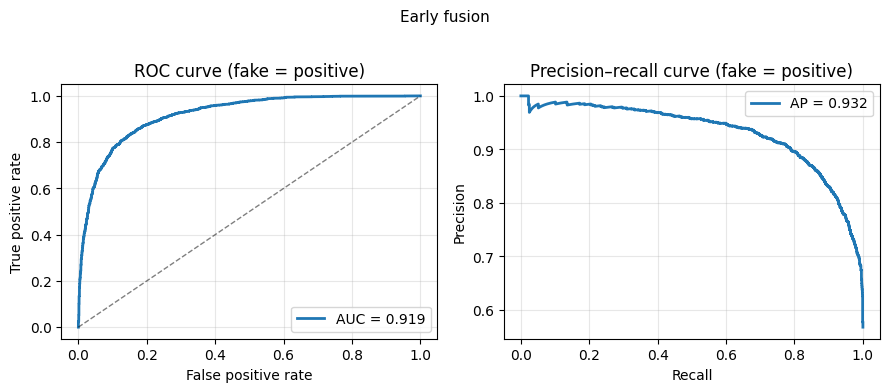

Persisted to Drive: /content/drive/MyDrive/runs/fusion_early_concat

Saved to /content/msc/runs/fusion_early_concat
{
  "accuracy": 0.8350423539901917,
  "macro_f1": 0.8339611482971769,
  "f1_real": 0.8205625606207565,
  "f1_fake": 0.8473597359735974,
  "recall_real": 0.8730650154798761,
  "recall_fake": 0.8061224489795918,
  "roc_auc": 0.9193225873345291,
  "average_precision": 0.9322297530503183,
  "run_id": "fusion_early_concat",
  "fusion_type": "early_concat_linear",
  "train_rows": 41382,
  "val_rows": 4486,
  "text_emb_dim": 768,
  "image_emb_dim": 512,
  "epochs": 8,
  "batch_size": 256,
  "learning_rate": 0.001,
  "random_seed": 42
}


In [8]:
# Step 3 — early fusion
import json

import matplotlib.pyplot as plt
import torch
from sklearn.metrics import classification_report, confusion_matrix

from colab_setup import persist_run_to_drive
from fusion_common import (
    FUSION_EARLY_RUN_ID,
    plot_validation_figures,
    save_run_artifacts,
    save_validation_figures,
)
from fusion_early import EarlyFusionConfig, run_early_fusion

if "train_df" not in globals() or "val_df" not in globals():
    raise RuntimeError("Run Step 1 first.")

if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config = EarlyFusionConfig(epochs=8, batch_size=256, learning_rate=1e-3)
metrics, early_head, y_pred, score_fake = run_early_fusion(
    train_df,
    val_df,
    project_root=PROJECT_ROOT,
    device=device,
    config=config,
)

y_val = val_df["label_binary"].to_numpy()
print("\nEarly fusion validation metrics (threshold=0.5):")
for k in (
    "accuracy",
    "macro_f1",
    "f1_real",
    "f1_fake",
    "recall_real",
    "recall_fake",
    "roc_auc",
    "average_precision",
):
    print(f"  {k}: {metrics[k]:.4f}")
print()
print(classification_report(y_val, y_pred, target_names=["real (0)", "fake (1)"]))

fig_cm, fig_curves = plot_validation_figures(
    y_val, y_pred, score_fake, title_prefix="Early fusion"
)
plt.show()

pred_out = val_df[["sample_id", "dataset"]].copy()
pred_out["y_true"] = y_val
pred_out["y_pred"] = y_pred
pred_out["score_fused"] = score_fake

run_dir = PROJECT_ROOT / "runs" / FUSION_EARLY_RUN_ID
run_dir.mkdir(parents=True, exist_ok=True)
torch.save(early_head.state_dict(), run_dir / "early_fusion_head.pt")
save_run_artifacts(run_dir, metrics=metrics, val_predictions=pred_out)
save_validation_figures(run_dir, fig_cm, fig_curves)
persist_run_to_drive(run_dir)

print("\nSaved to", run_dir)
print(json.dumps(metrics, indent=2))

---

## Step 4 — Attention fusion (softmax modality weights)

**Fusion point:** Feature level with **per-sample** text/image weights (softmax → sum to 1).

1. Same frozen embeddings as Step 3.
2. Project each modality to 256-d → **softmax attention** over {text, image}.
3. Weighted sum → linear classifier. Train attention + classifier on train only.

See `training/README.md` (Attention fusion). Metrics include `mean_attn_text` / `mean_attn_image`.

Extracting train embeddings (41382 rows)...
Extracting val embeddings (4486 rows)...
Training attention fusion head...
  epoch 1/8 train loss: 0.2755
  epoch 2/8 train loss: 0.2635
  epoch 3/8 train loss: 0.2600
  epoch 4/8 train loss: 0.2586
  epoch 5/8 train loss: 0.2519
  epoch 6/8 train loss: 0.2278
  epoch 7/8 train loss: 0.2157
  epoch 8/8 train loss: 0.2099

Attention fusion validation metrics (threshold=0.5):
  accuracy: 0.8493
  macro_f1: 0.8467
  f1_real: 0.8268
  f1_fake: 0.8667
  recall_real: 0.8323
  recall_fake: 0.8622
  roc_auc: 0.9230
  average_precision: 0.9360
  mean_attn_text:  0.733 | mean_attn_image: 0.267

              precision    recall  f1-score   support

    real (0)       0.82      0.83      0.83      1938
    fake (1)       0.87      0.86      0.87      2548

    accuracy                           0.85      4486
   macro avg       0.85      0.85      0.85      4486
weighted avg       0.85      0.85      0.85      4486



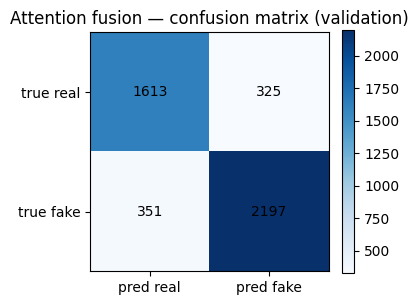

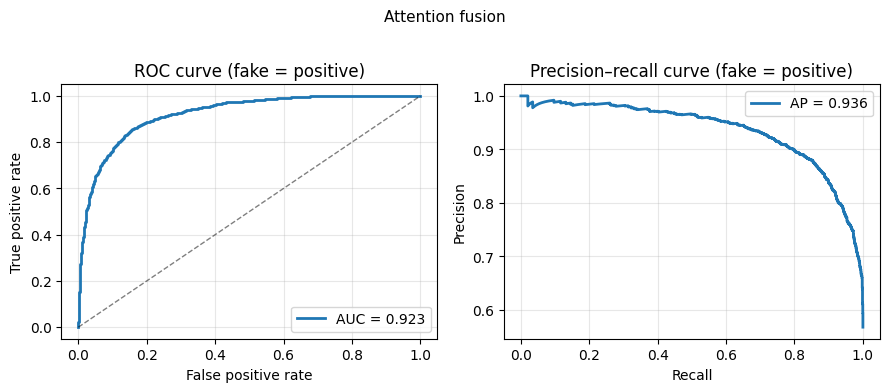

Persisted to Drive: /content/drive/MyDrive/runs/fusion_attention

Saved to /content/msc/runs/fusion_attention
{
  "accuracy": 0.8493089612126616,
  "macro_f1": 0.8467110883307706,
  "f1_real": 0.8267555099948745,
  "f1_fake": 0.8666666666666667,
  "recall_real": 0.8323013415892673,
  "recall_fake": 0.8622448979591837,
  "roc_auc": 0.9229953114849179,
  "average_precision": 0.9360082166555601,
  "run_id": "fusion_attention",
  "fusion_type": "attention_softmax",
  "train_rows": 41382,
  "val_rows": 4486,
  "proj_dim": 256,
  "softmax_temperature": 1.0,
  "use_layer_norm": false,
  "mean_attn_text": 0.7333659007414558,
  "mean_attn_image": 0.2666340995940363,
  "epochs": 8,
  "batch_size": 256,
  "learning_rate": 0.001,
  "random_seed": 42
}


In [9]:
# Step 4 — attention fusion
import json

import matplotlib.pyplot as plt
import torch
from sklearn.metrics import classification_report

from colab_setup import persist_run_to_drive
from fusion_attention import AttentionFusionConfig, run_attention_fusion
from fusion_common import (
    FUSION_ATTENTION_RUN_ID,
    plot_validation_figures,
    save_run_artifacts,
    save_validation_figures,
)

config = AttentionFusionConfig(proj_dim=256, epochs=8, batch_size=256, learning_rate=1e-3)
metrics, attn_head, y_pred, score_fake, attn_weights = run_attention_fusion(
    train_df,
    val_df,
    project_root=PROJECT_ROOT,
    device=device,
    config=config,
)

y_val = val_df["label_binary"].to_numpy()
print("\nAttention fusion validation metrics (threshold=0.5):")
for k in (
    "accuracy",
    "macro_f1",
    "f1_real",
    "f1_fake",
    "recall_real",
    "recall_fake",
    "roc_auc",
    "average_precision",
):
    print(f"  {k}: {metrics[k]:.4f}")
print(
    f"  mean_attn_text:  {metrics['mean_attn_text']:.3f} | "
    f"mean_attn_image: {metrics['mean_attn_image']:.3f}"
)
print()
print(classification_report(y_val, y_pred, target_names=["real (0)", "fake (1)"]))

fig_cm, fig_curves = plot_validation_figures(
    y_val, y_pred, score_fake, title_prefix="Attention fusion"
)
plt.show()

pred_out = val_df[["sample_id", "dataset"]].copy()
pred_out["y_true"] = y_val
pred_out["y_pred"] = y_pred
pred_out["score_fused"] = score_fake
pred_out["attn_text"] = attn_weights[:, 0]
pred_out["attn_image"] = attn_weights[:, 1]

run_dir = PROJECT_ROOT / "runs" / FUSION_ATTENTION_RUN_ID
run_dir.mkdir(parents=True, exist_ok=True)
torch.save(attn_head.state_dict(), run_dir / "attention_fusion_head.pt")
save_run_artifacts(run_dir, metrics=metrics, val_predictions=pred_out)
save_validation_figures(run_dir, fig_cm, fig_curves)
persist_run_to_drive(run_dir)

print("\nSaved to", run_dir)
print(json.dumps(metrics, indent=2))

---

## Step 5 — RQ2 / RQ3 summary

Loads `metrics.json` from fusion + unimodal runs. For strict RQ3, filter DistilBERT predictions to the same 4,486 multimodal val `sample_id`s.

In [10]:
# Step 5 — comparison table
import json

import pandas as pd
from IPython.display import display
from sklearn.metrics import recall_score

from fusion_common import (
    FUSION_ATTENTION_RUN_ID,
    FUSION_EARLY_RUN_ID,
    FUSION_LATE_RUN_ID,
    IMAGE_RUN_ID,
    TEXT_RUN_ID,
)

RUNS = PROJECT_ROOT / "runs"
rows: list[dict] = []


def _recall_from_predictions(run_dir) -> tuple[float | None, float | None]:
    """Fill recall columns when older metrics.json omit them."""
    pred_path = run_dir / "predictions_val.tsv"
    if not pred_path.is_file():
        return None, None
    pred = pd.read_csv(pred_path, sep="\t")
    if "y_true" not in pred.columns or "y_pred" not in pred.columns:
        return None, None
    y_true = pred["y_true"].to_numpy()
    y_pred = pred["y_pred"].to_numpy()
    return (
        float(recall_score(y_true, y_pred, pos_label=0)),
        float(recall_score(y_true, y_pred, pos_label=1)),
    )


def _load_metrics(run_id: str, label: str, group: str) -> None:
    run_dir = RUNS / run_id
    path = run_dir / "metrics.json"
    if not path.is_file():
        print("Missing:", path)
        return
    m = json.loads(path.read_text())
    recall_real = m.get("recall_real")
    recall_fake = m.get("recall_fake")
    if recall_real is None or recall_fake is None:
        from_pred = _recall_from_predictions(run_dir)
        if recall_real is None:
            recall_real = from_pred[0]
        if recall_fake is None:
            recall_fake = from_pred[1]
    rows.append(
        {
            "group": group,
            "method": label,
            "macro_f1": m.get("macro_f1"),
            "accuracy": m.get("accuracy"),
            "roc_auc": m.get("roc_auc"),
            "recall_real": recall_real,
            "recall_fake": recall_fake,
            "val_rows": m.get("val_rows"),
            "run_id": run_id,
        }
    )


_load_metrics(TEXT_RUN_ID, "Text — DistilBERT", "unimodal")
_load_metrics(IMAGE_RUN_ID, "Image — ResNet-18", "unimodal")
_load_metrics(FUSION_LATE_RUN_ID, "Late fusion (logistic)", "fusion")
_load_metrics(FUSION_EARLY_RUN_ID, "Early fusion (concat+linear)", "fusion")
_load_metrics(FUSION_ATTENTION_RUN_ID, "Attention fusion (softmax)", "fusion")

summary_df = pd.DataFrame(rows).sort_values(["group", "macro_f1"], ascending=[True, False])
display(summary_df)

,group,method,macro_f1,accuracy,roc_auc,recall_real,recall_fake,val_rows,run_id
4,fusion,Attention fusion (softmax),0.846711,0.849309,0.922995,0.832301,0.862245,4486,fusion_attention
2,fusion,Late fusion (logistic),0.838618,0.840615,0.914727,0.844169,0.837912,4486,fusion_late_logistic
3,fusion,Early fusion (concat+linear),0.833961,0.835042,0.919323,0.873065,0.806122,4486,fusion_early_concat
0,unimodal,Text — DistilBERT,0.827538,0.828530,0.903976,0.828125,0.828867,4788,text_distilbert_baseline
1,unimodal,Image — ResNet-18,0.714692,0.723584,0.780099,0.633127,0.792386,4486,image_resnet18_baseline
